🚀 Q1-LEVEL DUAL-SCENARIO EXTERNAL VALIDATION (A vs B)

⚙️ اعمال مهندسی ویژگی‌ها...
📊 Scenario A Features: 26 | Scenario B Features: 27

🎯 COMPARATIVE EXTERNAL VALIDATION METRICS MATRIX:
📊 Scenario A (Creatinine & Urea Free):
  • ROC-AUC          : 0.5328 (95% CI: 0.3726 - 0.6795)
  • Brier Score      : 0.2960
  • Optimal Cut-off  : 0.3478
  • Accuracy         : 0.5968
  • Sensitivity (TPR): 0.8710
  • Specificity (TNR): 0.3226
  • F1-Score         : 0.6835
--------------------------------------------------
📊 Scenario B (Creatinine-Free baseline):
  • ROC-AUC          : 0.8002 (95% CI: 0.6677 - 0.9240)
  • Brier Score      : 0.1805
  • Optimal Cut-off  : 0.5661
  • Accuracy         : 0.8387
  • Sensitivity (TPR): 0.7097
  • Specificity (TNR): 0.9677
  • F1-Score         : 0.8148
--------------------------------------------------



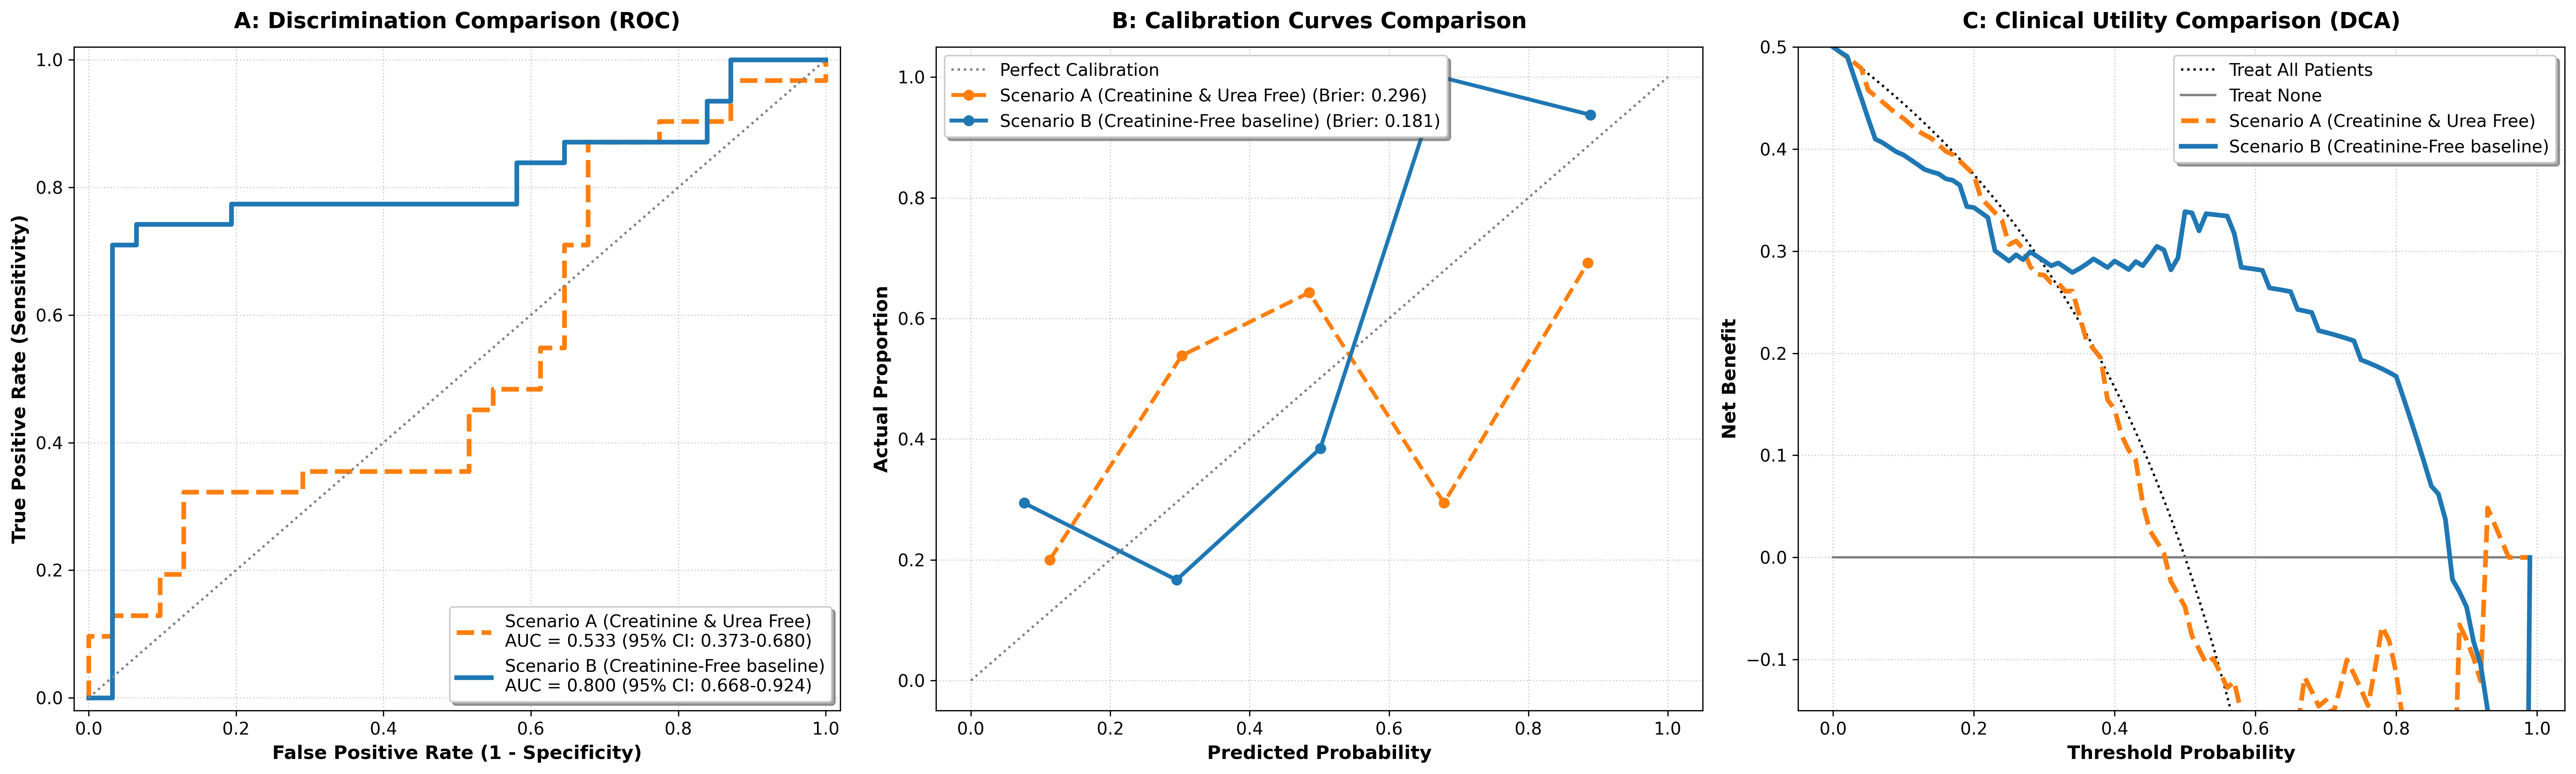

✅ پلات سه‌گانه مقایسه‌ای با موفقیت در فایل 'Scenario_A_vs_B_External_Validation_Q1.png' ذخیره شد.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, brier_score_loss, f1_score, accuracy_score, recall_score
from sklearn.calibration import calibration_curve
from lightgbm import LGBMClassifier

# ─────────────────────────────────────────────────────────────────────
# ۱. بارگذاری داده‌ها و استانداردسازی اولیه نام ستون‌ها
# ─────────────────────────────────────────────────────────────────────
development_path = "/content/DIABETIC_FOOT_ULCER_WBC_ADJUSTED_WAGNER_FIXED.xlsx"
external_path = "/content/گروه کیس_پاکسازی (1).xlsx"

print("============================================================")
print("🚀 Q1-LEVEL DUAL-SCENARIO EXTERNAL VALIDATION (A vs B)")
print("============================================================\n")

if not os.path.exists(development_path) or not os.path.exists(external_path):
    raise FileNotFoundError("لطفاً مطمئن شوید هر دو فایل دیتای توسعه و خارجی در مسیرها آپلود شده‌اند.")

df_dev_raw = pd.read_excel(development_path)
df_ext_raw = pd.read_excel(external_path)

# استانداردسازی نام ستون‌ها (حذف فضاهای خالی و بزرگ‌سازی حروف)
df_dev_raw.columns = df_dev_raw.columns.str.strip().str.upper()
df_ext_raw.columns = df_ext_raw.columns.str.strip().str.upper()

TARGET = "KIDNEY DISEASE"

# ─────────────────────────────────────────────────────────────────────
# ۲. تابع مهندسی ویژگی‌ها (منطبق بر کد پروژه اصلی شما)
# ─────────────────────────────────────────────────────────────────────
def run_project_feature_engineering(df_in):
    df = df_in.copy()
    if "CASE ID" in df.columns:
        df = df.drop(columns=["CASE ID"])

    lym = df["LYMPHOCYTE"].replace(0, np.nan)
    neu = df["NEUTROPHIL"]
    plt_s = df["PLATELET"]
    mon = df["MONOCYTE"]

    df["NLR"] = (neu / lym).clip(upper=(neu / lym).quantile(0.995))
    df["PLR"] = (plt_s / lym).clip(upper=(plt_s / lym).quantile(0.995))
    df["MLR"] = (mon / lym).clip(upper=(mon / lym).quantile(0.995))
    df["ELR"] = (df["EOSINOPHIL"] / lym).clip(upper=(df["EOSINOPHIL"] / lym).quantile(0.995))
    df["SII"] = ((neu * plt_s) / lym).clip(upper=((neu * plt_s) / lym).quantile(0.995))
    df["AISI"] = ((neu * mon * plt_s) / lym).clip(upper=((neu * mon * plt_s) / lym).quantile(0.995))

    df["HI"] = (df["WBC"] / df["HB"].replace(0, np.nan)).clip(upper=(df["WBC"] / df["HB"].replace(0, np.nan)).quantile(0.995))
    df["K_NA_RATIO"] = df["K"] / df["NA"].replace(0, np.nan)
    df["ANEMIA_SCORE"] = df["HB"] / (df["AGE"] / 65.0).replace(0, np.nan)

    return df

print("⚙️ اعمال مهندسی ویژگی‌ها...")
df_dev = run_project_feature_engineering(df_dev_raw)
df_ext = run_project_feature_engineering(df_ext_raw)

# متغیرهای پس از تشخیص (Post-Dx) که باید در هر دو سناریو حذف شوند
POST_DX = ["OUTCOME", "AMPUTATION", "LENGTH OF HOSPITALIZATION"]

# ─────────────────────────────────────────────────────────────────────
# ۳. تعریف و تفکیک ویژگی‌های سناریو A و سناریو B
# ─────────────────────────────────────────────────────────────────────
# سناریو B: بدون کراتینین (شامل اوره)
features_b = [c for c in df_dev.columns if c != TARGET and c not in POST_DX + ["CREATININ"]]

# سناریو A: بدون کراتینین و بدون اوره
features_a = [c for c in features_b if c != "UREA"]

print(f"📊 Scenario A Features: {len(features_a)} | Scenario B Features: {len(features_b)}")

# دیکشنری برای ذخیره نتایج نهایی پلات‌ها
results = {}

# ─────────────────────────────────────────────────────────────────────
# ۴. اجرای خط لوله ارزیابی برای هر دو سناریو به صورت اتوماتیک
# ─────────────────────────────────────────────────────────────────────
for scenario_name, features in [("Scenario A (Creatinine & Urea Free)", features_a),
                                ("Scenario B (Creatinine-Free baseline)", features_b)]:

    X_dev = df_dev[features].copy()
    y_dev = df_dev[TARGET].values
    X_ext = df_ext[features].copy()
    y_ext = df_ext[TARGET].values

    # امپیوتیشن مقادیر خالی با میانه دیتای توسعه
    for col in features:
        median_val = X_dev[col].median()
        X_dev[col] = X_dev[col].fillna(median_val)
        X_ext[col] = X_ext[col].fillna(median_val)

    # آموزش مدل
    model = LGBMClassifier(n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1)
    model.fit(X_dev, y_dev)

    # پیش‌بینی احتمالات خارجی
    y_prob_ext = model.predict_proba(X_ext)[:, 1]

    # محاسبات آمارهای تفکیک (AUC) با بوت‌استرپینگ
    fpr, tpr, thresholds = roc_curve(y_ext, y_prob_ext)
    roc_auc = auc(fpr, tpr)

    n_bootstraps = 1000
    rng = np.random.RandomState(42)
    bootstrapped_aucs = []
    for i in range(n_bootstraps):
        indices = rng.randint(0, len(y_ext), len(y_ext))
        if len(np.unique(y_ext[indices])) < 2:
            continue
        score = auc(*roc_curve(y_ext[indices], y_prob_ext[indices])[:2])
        bootstrapped_aucs.append(score)

    sorted_aucs = np.sort(bootstrapped_aucs)
    ci_lower = sorted_aucs[int(0.025 * len(sorted_aucs))]
    ci_upper = sorted_aucs[int(0.975 * len(sorted_aucs))]

    # کالیبراسیون و برش بهینه
    brier = brier_score_loss(y_ext, y_prob_ext)
    youden_idx = tpr - fpr
    opt_idx = np.argmax(youden_idx)
    cutoff_opt = thresholds[opt_idx]

    y_pred_opt = (y_prob_ext >= cutoff_opt).astype(int)
    acc = accuracy_score(y_ext, y_pred_opt)
    sens = recall_score(y_ext, y_pred_opt)
    spec = recall_score(y_ext, y_pred_opt, pos_label=0)
    f1 = f1_score(y_ext, y_pred_opt)

    # ذخیره نتایج آماری برای نمودارها
    results[scenario_name] = {
        'fpr': fpr, 'tpr': tpr, 'auc': roc_auc, 'ci_lower': ci_lower, 'ci_upper': ci_upper,
        'brier': brier, 'y_prob_ext': y_prob_ext, 'y_ext': y_ext,
        'acc': acc, 'sens': sens, 'spec': spec, 'f1': f1, 'cutoff': cutoff_opt
    }

# ─────────────────────────────────────────────────────────────────────
# ۵. چاپ جدول مقایسه‌ای نتایج نهایی (بسیار شکیل برای مقاله)
# ─────────────────────────────────────────────────────────────────────
print("\n" + "="*75)
print("🎯 COMPARATIVE EXTERNAL VALIDATION METRICS MATRIX:")
print("="*75)
for name, data in results.items():
    print(f"📊 {name}:")
    print(f"  • ROC-AUC          : {data['auc']:.4f} (95% CI: {data['ci_lower']:.4f} - {data['ci_upper']:.4f})")
    print(f"  • Brier Score      : {data['brier']:.4f}")
    print(f"  • Optimal Cut-off  : {data['cutoff']:.4f}")
    print(f"  • Accuracy         : {data['acc']:.4f}")
    print(f"  • Sensitivity (TPR): {data['sens']:.4f}")
    print(f"  • Specificity (TNR): {data['spec']:.4f}")
    print(f"  • F1-Score         : {data['f1']:.4f}")
    print("-" * 50)
print("="*75 + "\n")

# ─────────────────────────────────────────────────────────────────────
# ۶. تصویرسازی سه‌گانه مقایسه‌ای هردو سناریو (300 DPI)
# ─────────────────────────────────────────────────────────────────────
fig, axs = plt.subplots(1, 3, figsize=(23, 7), dpi=300)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11

colors = {'Scenario A (Creatinine & Urea Free)': '#ff7f0e', 'Scenario B (Creatinine-Free baseline)': '#1f77b4'}
styles = {'Scenario A (Creatinine & Urea Free)': '--', 'Scenario B (Creatinine-Free baseline)': '-'}

# --- نمودار A: ROC Comparison ---
for name, data in results.items():
    axs[0].plot(data['fpr'], data['tpr'], color=colors[name], linestyle=styles[name], lw=3,
                label=f"{name}\nAUC = {data['auc']:.3f} (95% CI: {data['ci_lower']:.3f}-{data['ci_upper']:.3f})")
axs[0].plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle=':')
axs[0].set_xlim([-0.02, 1.02])
axs[0].set_ylim([-0.02, 1.02])
axs[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
axs[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
axs[0].set_title('A: Discrimination Comparison (ROC)', fontsize=14, fontweight='bold', pad=12)
axs[0].legend(loc="lower right", frameon=True, shadow=True)
axs[0].grid(True, linestyle=':', alpha=0.6)

# --- نمودار B: Calibration Comparison ---
axs[1].plot([0, 1], [0, 1], linestyle=':', color='gray', label='Perfect Calibration')
for name, data in results.items():
    prob_true, prob_pred = calibration_curve(data['y_ext'], data['y_prob_ext'], n_bins=5, strategy='uniform')
    axs[1].plot(prob_pred, prob_true, marker='o', markersize=6, linewidth=2.5, color=colors[name],
                linestyle=styles[name], label=f"{name} (Brier: {data['brier']:.3f})")
axs[1].set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
axs[1].set_ylabel('Actual Proportion', fontsize=12, fontweight='bold')
axs[1].set_title('B: Calibration Curves Comparison', fontsize=14, fontweight='bold', pad=12)
axs[1].legend(loc="upper left", frameon=True, shadow=True)
axs[1].grid(True, linestyle=':', alpha=0.6)

# --- نمودار C: Decision Curve Analysis (DCA) Comparison ---
thresholds_dca = np.linspace(0, 0.99, 100)
n_samples = len(df_ext)
y_true_dca = df_ext[TARGET].values
pt_actual = np.mean(y_true_dca)

# خطوط مرجع استراتژی بالینی
net_benefit_all = []
for t in thresholds_dca:
    tp_all = np.sum(y_true_dca == 1)
    fp_all = np.sum(y_true_dca == 0)
    nb_a = (tp_all / n_samples) - (fp_all / n_samples) * (t / (1 - t)) if t < 1 else 0
    net_benefit_all.append(nb_a)

axs[2].plot(thresholds_dca, net_benefit_all, color='black', lw=1.5, linestyle=':', label='Treat All Patients')
axs[2].plot(thresholds_dca, [0]*len(thresholds_dca), color='gray', lw=1.5, label='Treat None')

# ترسیم DCA برای هر مدل
for name, data in results.items():
    net_benefit_model = []
    for t in thresholds_dca:
        y_pred_t = (data['y_prob_ext'] >= t).astype(int)
        tp = np.sum((y_pred_t == 1) & (data['y_ext'] == 1))
        fp = np.sum((y_pred_t == 1) & (data['y_ext'] == 0))
        nb_m = (tp / n_samples) - (fp / n_samples) * (t / (1 - t)) if t < 1 else 0
        net_benefit_model.append(nb_m)
    axs[2].plot(thresholds_dca, net_benefit_model, color=colors[name], lw=3, linestyle=styles[name], label=name)

axs[2].set_ylim([-0.15, max(pt_actual, 0.4)])
axs[2].set_xlabel('Threshold Probability', fontsize=12, fontweight='bold')
axs[2].set_ylabel('Net Benefit', fontsize=12, fontweight='bold')
axs[2].set_title('C: Clinical Utility Comparison (DCA)', fontsize=14, fontweight='bold', pad=12)
axs[2].legend(loc="upper right", frameon=True, shadow=True)
axs[2].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
output_fig = 'Scenario_A_vs_B_External_Validation_Q1.png'
plt.savefig(output_fig, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ پلات سه‌گانه مقایسه‌ای با موفقیت در فایل '{output_fig}' ذخیره شد.")

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_curve, auc, brier_score_loss, f1_score,
                             accuracy_score, recall_score, confusion_matrix,
                             classification_report, roc_auc_score)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from lightgbm import LGBMClassifier
import shap
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────
# ۱. بارگذاری داده‌ها و استانداردسازی
# ─────────────────────────────────────────────────────────────────────
development_path = "/content/DIABETIC_FOOT_ULCER_WBC_ADJUSTED_WAGNER_FIXED.xlsx"
external_path = "/content/گروه کیس_پاکسازی (1).xlsx"

print("="*80)
print("🚀 COMPREHENSIVE Q1-LEVEL DUAL-SCENARIO EXTERNAL VALIDATION")
print("DFU Kidney Dysfunction: Creatinine-Free Prediction Framework")
print("="*80 + "\n")

if not os.path.exists(development_path) or not os.path.exists(external_path):
    raise FileNotFoundError("⚠️ فایل‌های داده موجود نیستند.")

df_dev_raw = pd.read_excel(development_path)
df_ext_raw = pd.read_excel(external_path)

df_dev_raw.columns = df_dev_raw.columns.str.strip().str.upper()
df_ext_raw.columns = df_ext_raw.columns.str.strip().str.upper()

TARGET = "KIDNEY DISEASE"

# ─────────────────────────────────────────────────────────────────────
# ۲. Feature Engineering
# ─────────────────────────────────────────────────────────────────────
def run_project_feature_engineering(df_in):
    df = df_in.copy()
    if "CASE ID" in df.columns:
        df = df.drop(columns=["CASE ID"])

    lym = df["LYMPHOCYTE"].replace(0, np.nan)
    neu = df["NEUTROPHIL"]
    plt_s = df["PLATELET"]
    mon = df["MONOCYTE"]

    df["NLR"] = (neu / lym).clip(upper=(neu / lym).quantile(0.995))
    df["PLR"] = (plt_s / lym).clip(upper=(plt_s / lym).quantile(0.995))
    df["MLR"] = (mon / lym).clip(upper=(mon / lym).quantile(0.995))
    df["ELR"] = (df["EOSINOPHIL"] / lym).clip(upper=(df["EOSINOPHIL"] / lym).quantile(0.995))
    df["SII"] = ((neu * plt_s) / lym).clip(upper=((neu * plt_s) / lym).quantile(0.995))
    df["AISI"] = ((neu * mon * plt_s) / lym).clip(upper=((neu * mon * plt_s) / lym).quantile(0.995))
    df["HI"] = (df["WBC"] / df["HB"].replace(0, np.nan)).clip(upper=(df["WBC"] / df["HB"].replace(0, np.nan)).quantile(0.995))
    df["K_NA_RATIO"] = df["K"] / df["NA"].replace(0, np.nan)
    df["ANEMIA_SCORE"] = df["HB"] / (df["AGE"] / 65.0).replace(0, np.nan)

    return df

print("⚙️ اعمال Feature Engineering...")
df_dev = run_project_feature_engineering(df_dev_raw)
df_ext = run_project_feature_engineering(df_ext_raw)

# متغیرهای بعد از تشخیص
POST_DX = ["OUTCOME", "AMPUTATION", "LENGTH OF HOSPITALIZATION"]

# تفکیک Features
features_b = [c for c in df_dev.columns if c != TARGET and c not in POST_DX + ["CREATININ"]]
features_a = [c for c in features_b if c != "UREA"]

print(f"📊 Scenario A Features: {len(features_a)} | Scenario B Features: {len(features_b)}\n")

# ─────────────────────────────────────────────────────────────────────
# ۳. Data Quality Report
# ─────────────────────────────────────────────────────────────────────
print("="*80)
print("📋 DATA QUALITY REPORT")
print("="*80)
print(f"\n📈 Development Set: n={len(df_dev)}, Cases={df_dev[TARGET].sum()}, Controls={(df_dev[TARGET]==0).sum()}")
print(f"   Prevalence: {df_dev[TARGET].mean()*100:.1f}%")
print(f"\n📈 External Validation Set: n={len(df_ext)}, Cases={df_ext[TARGET].sum()}, Controls={(df_ext[TARGET]==0).sum()}")
print(f"   Prevalence: {df_ext[TARGET].mean()*100:.1f}%")

# Missing Data Analysis
print("\n🔍 Missing Data Analysis (External Cohort):")
missing_pct = (df_ext[features_b].isnull().sum() / len(df_ext) * 100).sort_values(ascending=False)
if missing_pct.max() > 0:
    print(missing_pct[missing_pct > 0].to_string())
else:
    print("✅ کاملاً بدون Missing Data")

# ─────────────────────────────────────────────────────────────────────
# ۴. Main Validation Pipeline
# ─────────────────────────────────────────────────────────────────────
results = {}
models = {}

for scenario_name, features in [("Scenario A (Creatinine & Urea Free)", features_a),
                                ("Scenario B (Creatinine-Free baseline)", features_b)]:

    print(f"\n{'='*80}")
    print(f"🔬 {scenario_name}")
    print(f"{'='*80}")

    # ─── Prepare Data ───
    X_dev = df_dev[features].copy()
    y_dev = df_dev[TARGET].values
    X_ext = df_ext[features].copy()
    y_ext = df_ext[TARGET].values

    # Imputation
    for col in features:
        median_val = X_dev[col].median()
        X_dev[col] = X_dev[col].fillna(median_val)
        X_ext[col] = X_ext[col].fillna(median_val)

    # ─── Model Training ───
    model = LGBMClassifier(n_estimators=100, learning_rate=0.05,
                          random_state=42, verbose=-1, class_weight='balanced')
    model.fit(X_dev, y_dev)
    models[scenario_name] = model

    # ─── Development Set Performance ───
    y_prob_dev = model.predict_proba(X_dev)[:, 1]
    fpr_dev, tpr_dev, _ = roc_curve(y_dev, y_prob_dev)
    auc_dev = auc(fpr_dev, tpr_dev)

    # Cross-validation performance (internal validation)
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    y_prob_cv = cross_val_predict(model, X_dev, y_dev, cv=skf, method='predict_proba')[:, 1]
    auc_cv = roc_auc_score(y_dev, y_prob_cv)

    # ─── External Validation Performance ───
    y_prob_ext = model.predict_proba(X_ext)[:, 1]
    fpr_ext, tpr_ext, thresholds_ext = roc_curve(y_ext, y_prob_ext)
    roc_auc_ext = auc(fpr_ext, tpr_ext)

    # ─── Bootstrap Confidence Intervals ───
    n_bootstraps = 1000
    rng = np.random.RandomState(42)
    bootstrapped_aucs = []
    for i in range(n_bootstraps):
        indices = rng.randint(0, len(y_ext), len(y_ext))
        if len(np.unique(y_ext[indices])) < 2:
            continue
        score = roc_auc_score(y_ext[indices], y_prob_ext[indices])
        bootstrapped_aucs.append(score)

    sorted_aucs = np.sort(bootstrapped_aucs)
    ci_lower = sorted_aucs[int(0.025 * len(sorted_aucs))]
    ci_upper = sorted_aucs[int(0.975 * len(sorted_aucs))]

    # ─── Calibration Metrics ───
    brier = brier_score_loss(y_ext, y_prob_ext)
    prob_true, prob_pred = calibration_curve(y_ext, y_prob_ext, n_bins=10, strategy='uniform')

    # Hosmer-Lemeshow test
    from scipy.stats import chi2
    n_bins = 10
    y_true_binned = pd.cut(y_prob_ext, bins=np.linspace(0, 1, n_bins+1), labels=False, include_lowest=True)
    hl_stat = 0
    for bin_idx in range(n_bins):
        mask = y_true_binned == bin_idx
        if mask.sum() > 0:
            o_event = (y_ext[mask] == 1).sum()
            e_event = y_prob_ext[mask].sum()
            o_nonevent = (y_ext[mask] == 0).sum()
            e_nonevent = (~mask).sum() * (1 - y_prob_ext[~mask].mean()) if (~mask).sum() > 0 else 0
            if e_event > 0 and e_nonevent > 0:
                hl_stat += ((o_event - e_event)**2 / e_event) + ((o_nonevent - e_nonevent)**2 / e_nonevent)

    hl_pvalue = 1 - chi2.cdf(hl_stat, df=n_bins-2)

    # ─── Optimal Threshold (Youden Index) ───
    youden_idx = tpr_ext - fpr_ext
    opt_idx = np.argmax(youden_idx)
    cutoff_opt = thresholds_ext[opt_idx]

    # ─── Performance at Optimal Threshold ───
    y_pred_opt = (y_prob_ext >= cutoff_opt).astype(int)
    tn = ((y_pred_opt == 0) & (y_ext == 0)).sum()
    fp = ((y_pred_opt == 1) & (y_ext == 0)).sum()
    fn = ((y_pred_opt == 0) & (y_ext == 1)).sum()
    tp = ((y_pred_opt == 1) & (y_ext == 1)).sum()

    acc = accuracy_score(y_ext, y_pred_opt)
    sens = recall_score(y_ext, y_pred_opt)
    spec = recall_score(y_ext, y_pred_opt, pos_label=0)
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    f1 = f1_score(y_ext, y_pred_opt)
    youden = sens + spec - 1

    # ─── Store Results ───
    results[scenario_name] = {
        'model': model,
        'features': features,
        'X_dev': X_dev, 'y_dev': y_dev,
        'X_ext': X_ext, 'y_ext': y_ext,
        'y_prob_dev': y_prob_dev,
        'y_prob_ext': y_prob_ext,
        'auc_dev': auc_dev,
        'auc_cv': auc_cv,
        'auc_ext': roc_auc_ext,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'brier': brier,
        'hl_pvalue': hl_pvalue,
        'fpr': fpr_ext,
        'tpr': tpr_ext,
        'y_pred_opt': y_pred_opt,
        'cutoff': cutoff_opt,
        'acc': acc,
        'sens': sens,
        'spec': spec,
        'ppv': ppv,
        'npv': npv,
        'f1': f1,
        'youden': youden,
        'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn,
        'prob_true_calib': prob_true,
        'prob_pred_calib': prob_pred
    }

# ─────────────────────────────────────────────────────────────────────
# ۵. Main Results Table (Publication Quality)
# ─────────────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("🎯 COMPREHENSIVE PERFORMANCE COMPARISON")
print("="*80)

metrics_df = pd.DataFrame({
    scenario: {
        'Development AUC': f"{data['auc_dev']:.4f}",
        'CV AUC (10-fold)': f"{data['auc_cv']:.4f}",
        'External AUC': f"{data['auc_ext']:.4f} (95% CI: {data['ci_lower']:.4f}-{data['ci_upper']:.4f})",
        'Brier Score': f"{data['brier']:.4f}",
        'Hosmer-Lemeshow p': f"{data['hl_pvalue']:.4f}",
        'Optimal Cutoff': f"{data['cutoff']:.4f}",
        'Sensitivity': f"{data['sens']:.4f}",
        'Specificity': f"{data['spec']:.4f}",
        'PPV': f"{data['ppv']:.4f}",
        'NPV': f"{data['npv']:.4f}",
        'Accuracy': f"{data['acc']:.4f}",
        'F1-Score': f"{data['f1']:.4f}",
        'Youden Index': f"{data['youden']:.4f}"
    }
    for scenario, data in results.items()
})

print("\n" + metrics_df.to_string())
print("\n")

# ─────────────────────────────────────────────────────────────────────
# ۶. Threshold Analysis Table
# ─────────────────────────────────────────────────────────────────────
print("="*80)
print("📊 THRESHOLD ANALYSIS (Scenario B)")
print("="*80)

scenario_b_name = "Scenario B (Creatinine-Free baseline)"
scenario_b_data = results[scenario_b_name]
y_prob_sb = scenario_b_data['y_prob_ext']
y_true_sb = scenario_b_data['y_ext']

thresholds_to_test = [0.30, 0.40, 0.50, scenario_b_data['cutoff'], 0.60, 0.70]
threshold_results = []

for th in thresholds_to_test:
    y_pred_th = (y_prob_sb >= th).astype(int)
    tp_th = ((y_pred_th == 1) & (y_true_sb == 1)).sum()
    fp_th = ((y_pred_th == 1) & (y_true_sb == 0)).sum()
    tn_th = ((y_pred_th == 0) & (y_true_sb == 0)).sum()
    fn_th = ((y_pred_th == 0) & (y_true_sb == 1)).sum()

    sens_th = tp_th / (tp_th + fn_th) if (tp_th + fn_th) > 0 else 0
    spec_th = tn_th / (tn_th + fp_th) if (tn_th + fp_th) > 0 else 0
    ppv_th = tp_th / (tp_th + fp_th) if (tp_th + fp_th) > 0 else 0
    npv_th = tn_th / (tn_th + fn_th) if (tn_th + fn_th) > 0 else 0
    youden_th = sens_th + spec_th - 1

    threshold_results.append({
        'Threshold': f"{th:.4f}" + (" *optimal" if abs(th - scenario_b_data['cutoff']) < 0.001 else ""),
        'Sensitivity': f"{sens_th:.4f}",
        'Specificity': f"{spec_th:.4f}",
        'PPV': f"{ppv_th:.4f}",
        'NPV': f"{npv_th:.4f}",
        'Youden': f"{youden_th:.4f}"
    })

threshold_df = pd.DataFrame(threshold_results)
print("\n" + threshold_df.to_string(index=False))

# ─────────────────────────────────────────────────────────────────────
# ۷. Feature Importance Analysis (SHAP + Permutation)
# ─────────────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("🔍 FEATURE IMPORTANCE ANALYSIS")
print("="*80)

for scenario_name, data in results.items():
    print(f"\n📈 {scenario_name}:")

    model = data['model']
    X_ext_scenario = data['X_ext']
    features = data['features']

    # LightGBM feature importance
    feature_imp = pd.DataFrame({
        'Feature': features,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print("\nTop 10 Features (LightGBM Gain):")
    print(feature_imp.head(10).to_string(index=False))

    # Permutation importance
    perm_imp = permutation_importance(model, X_ext_scenario, data['y_ext'],
                                     n_repeats=10, random_state=42, n_jobs=-1)
    perm_imp_df = pd.DataFrame({
        'Feature': features,
        'Permutation_Importance': perm_imp.importances_mean
    }).sort_values('Permutation_Importance', ascending=False)

    print("\nTop 10 Features (Permutation):")
    print(perm_imp_df.head(10).to_string(index=False))

# ─────────────────────────────────────────────────────────────────────
# ۸. SHAP Analysis (Explainability)
# ─────────────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("💡 SHAP EXPLAINABILITY ANALYSIS")
print("="*80)

for scenario_name, data in results.items():
    print(f"\n🔬 Computing SHAP values for {scenario_name}...")

    try:
        model = data['model']
        X_ext_scenario = data['X_ext']
        features = data['features']

        # Use a sample for faster computation
        sample_size = min(100, len(X_ext_scenario))
        X_sample = X_ext_scenario.sample(n=sample_size, random_state=42)

        explainer = shap.TreeExplainer(model)
        shap_values_raw = explainer.shap_values(X_sample)

        # Handle binary classification (returns list of 2 arrays or single array)
        if isinstance(shap_values_raw, list):
            # For binary classification, use class 1 (positive class/disease)
            if len(shap_values_raw) >= 2:
                shap_vals_disease = shap_values_raw[1]
                shap_values_list = shap_values_raw
            else:
                shap_vals_disease = shap_values_raw[0]
                shap_values_list = shap_values_raw
        else:
            # If it's an array (not a list)
            shap_vals_disease = shap_values_raw
            shap_values_list = [shap_values_raw]

        # Mean absolute SHAP values
        mean_abs_shap = np.abs(shap_vals_disease).mean(axis=0)
        shap_importance = pd.DataFrame({
            'Feature': features,
            'Mean_|SHAP|': mean_abs_shap
        }).sort_values('Mean_|SHAP|', ascending=False)

        print(f"\nTop 10 Features (SHAP |Mean| Values):")
        print(shap_importance.head(10).to_string(index=False))

        # Store for visualization
        results[scenario_name]['shap_values'] = shap_values_list
        results[scenario_name]['shap_vals_disease'] = shap_vals_disease
        results[scenario_name]['shap_explainer'] = explainer
        results[scenario_name]['X_sample'] = X_sample
        results[scenario_name]['shap_importance_df'] = shap_importance

    except Exception as e:
        print(f"⚠️  خطا در محاسبه SHAP برای {scenario_name}: {str(e)}")
        results[scenario_name]['shap_values'] = None
        results[scenario_name]['shap_vals_disease'] = None

# ─────────────────────────────────────────────────────────────────────
# ۹. Comprehensive Visualizations (Publication Quality)
# ─────────────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("📊 GENERATING PUBLICATION-QUALITY VISUALIZATIONS...")
print("="*80)

# ─── Figure 1: ROC, Calibration, DCA ───
fig, axs = plt.subplots(1, 3, figsize=(24, 7), dpi=300)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 12

colors = {
    'Scenario A (Creatinine & Urea Free)': '#ff7f0e',
    'Scenario B (Creatinine-Free baseline)': '#1f77b4'
}
styles = {
    'Scenario A (Creatinine & Urea Free)': '--',
    'Scenario B (Creatinine-Free baseline)': '-'
}

# --- Panel A: ROC Curves ---
for scenario_name, data in results.items():
    axs[0].plot(data['fpr'], data['tpr'], color=colors[scenario_name],
                linestyle=styles[scenario_name], lw=3,
                label=f"{scenario_name}\nAUC = {data['auc_ext']:.3f} (95% CI: {data['ci_lower']:.3f}-{data['ci_upper']:.3f})")

axs[0].plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle=':', label='No Discrimination')
axs[0].fill_between([0, 1], 0, 1, alpha=0.05, color='gray')
axs[0].set_xlim([-0.02, 1.02])
axs[0].set_ylim([-0.02, 1.02])
axs[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=13, fontweight='bold')
axs[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=13, fontweight='bold')
axs[0].set_title('A: External Validation ROC Curves', fontsize=14, fontweight='bold', pad=12)
axs[0].legend(loc="lower right", frameon=True, shadow=True, fontsize=11)
axs[0].grid(True, linestyle=':', alpha=0.4)
axs[0].set_aspect('equal')

# --- Panel B: Calibration Curves ---
axs[1].plot([0, 1], [0, 1], linestyle=':', color='gray', lw=2, label='Perfect Calibration')
for scenario_name, data in results.items():
    axs[1].plot(data['prob_pred_calib'], data['prob_true_calib'], marker='o',
                markersize=8, linewidth=2.5, color=colors[scenario_name],
                linestyle=styles[scenario_name],
                label=f"{scenario_name}\n(Brier: {data['brier']:.3f}, HL p={data['hl_pvalue']:.3f})")

axs[1].set_xlim([-0.02, 1.02])
axs[1].set_ylim([-0.02, 1.02])
axs[1].set_xlabel('Predicted Probability', fontsize=13, fontweight='bold')
axs[1].set_ylabel('Actual Proportion', fontsize=13, fontweight='bold')
axs[1].set_title('B: Calibration Curves\n(External Validation)', fontsize=14, fontweight='bold', pad=12)
axs[1].legend(loc="upper left", frameon=True, shadow=True, fontsize=11)
axs[1].grid(True, linestyle=':', alpha=0.4)
axs[1].set_aspect('equal')

# --- Panel C: DCA Curves ---
thresholds_dca = np.linspace(0, 0.99, 100)
n_samples = len(df_ext)
y_true_dca = df_ext[TARGET].values
pt_actual = np.mean(y_true_dca)

# Reference lines
net_benefit_all = []
for t in thresholds_dca:
    if t >= 1:
        continue
    tp_all = np.sum(y_true_dca == 1)
    fp_all = np.sum(y_true_dca == 0)
    nb_a = (tp_all / n_samples) - (fp_all / n_samples) * (t / (1 - t))
    net_benefit_all.append(nb_a)

axs[2].plot(thresholds_dca, net_benefit_all, color='black', lw=2,
            linestyle=':', label='Treat All', zorder=2)
axs[2].plot(thresholds_dca, [0]*len(thresholds_dca), color='gray', lw=2,
            linestyle='--', label='Treat None')

# Model DCA curves
for scenario_name, data in results.items():
    net_benefit_model = []
    for t in thresholds_dca:
        if t >= 1:
            continue
        y_pred_t = (data['y_prob_ext'] >= t).astype(int)
        tp = np.sum((y_pred_t == 1) & (data['y_ext'] == 1))
        fp = np.sum((y_pred_t == 1) & (data['y_ext'] == 0))
        nb_m = (tp / n_samples) - (fp / n_samples) * (t / (1 - t))
        net_benefit_model.append(nb_m)

    axs[2].plot(thresholds_dca[:len(net_benefit_model)], net_benefit_model,
                color=colors[scenario_name], lw=3, linestyle=styles[scenario_name],
                label=scenario_name, zorder=3)

axs[2].set_ylim([-0.15, max(pt_actual, 0.4)])
axs[2].set_xlabel('Threshold Probability', fontsize=13, fontweight='bold')
axs[2].set_ylabel('Net Benefit', fontsize=13, fontweight='bold')
axs[2].set_title('C: Decision Curve Analysis\n(Clinical Utility)', fontsize=14, fontweight='bold', pad=12)
axs[2].legend(loc="upper right", frameon=True, shadow=True, fontsize=11)
axs[2].grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
fig.savefig('Figure_1_ROC_Calibration_DCA.png', dpi=300, bbox_inches='tight')
print("✅ Figure 1 (ROC, Calibration, DCA) saved")
plt.close()

# ─── Figure 2: Confusion Matrices ───
fig, axs = plt.subplots(1, 2, figsize=(14, 6), dpi=300)

for idx, (scenario_name, data) in enumerate(results.items()):
    cm = np.array([[data['tn'], data['fp']],
                    [data['fn'], data['tp']]])
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', ax=axs[idx],
                cbar_kws={'label': 'Proportion'},
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
                annot_kws={'size': 14, 'fontweight': 'bold'})

    axs[idx].set_title(f"{scenario_name}\n(Cutoff={data['cutoff']:.3f})",
                       fontsize=13, fontweight='bold')
    axs[idx].set_ylabel('True Label', fontsize=12, fontweight='bold')
    axs[idx].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')

plt.tight_layout()
fig.savefig('Figure_2_Confusion_Matrices.png', dpi=300, bbox_inches='tight')
print("✅ Figure 2 (Confusion Matrices) saved")
plt.close()

# ─── Figure 3: Predicted Probability Distributions ───
fig, axs = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

for idx, (scenario_name, data) in enumerate(results.items()):
    y_prob = data['y_prob_ext']
    y_true = data['y_ext']

    axs[idx].hist(y_prob[y_true == 0], bins=20, alpha=0.6, label='No Disease', color='green', edgecolor='black')
    axs[idx].hist(y_prob[y_true == 1], bins=20, alpha=0.6, label='Disease', color='red', edgecolor='black')
    axs[idx].axvline(data['cutoff'], color='blue', linestyle='--', linewidth=2.5, label=f'Optimal Cutoff ({data["cutoff"]:.3f})')

    axs[idx].set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
    axs[idx].set_ylabel('Frequency', fontsize=12, fontweight='bold')
    axs[idx].set_title(f"{scenario_name}\n(AUC={data['auc_ext']:.3f})", fontsize=13, fontweight='bold')
    axs[idx].legend(fontsize=11, loc='upper center')
    axs[idx].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig('Figure_3_Probability_Distributions.png', dpi=300, bbox_inches='tight')
print("✅ Figure 3 (Predicted Probability Distributions) saved")
plt.close()

# ─── Figure 4: Feature Importance Comparison ───
fig, axs = plt.subplots(1, 2, figsize=(18, 8), dpi=300)

for idx, (scenario_name, data) in enumerate(results.items()):
    model = data['model']
    features = data['features']

    feature_imp = pd.DataFrame({
        'Feature': features,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=True).tail(15)

    axs[idx].barh(feature_imp['Feature'], feature_imp['Importance'],
                   color=colors[scenario_name], edgecolor='black', linewidth=1.2)
    axs[idx].set_xlabel('Feature Importance (Gain)', fontsize=12, fontweight='bold')
    axs[idx].set_title(f"{scenario_name}\n(Top 15 Features)", fontsize=13, fontweight='bold')
    axs[idx].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
fig.savefig('Figure_4_Feature_Importance.png', dpi=300, bbox_inches='tight')
print("✅ Figure 4 (Feature Importance) saved")
plt.close()

# ─── Figure 5: SHAP Summary Plots ───
fig, axs = plt.subplots(1, 2, figsize=(18, 8), dpi=300)

for idx, (scenario_name, data) in enumerate(results.items()):
    if data['shap_vals_disease'] is None:
        print(f"⏭️  SHAP plot برای {scenario_name} skip می‌شود (خطا در محاسبه)")
        continue

    shap_vals = data['shap_vals_disease']
    features = data['features']

    # Mean absolute SHAP
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)
    top_indices = np.argsort(mean_abs_shap)[-12:][::-1]

    top_features = [features[i] for i in top_indices]
    top_shap = mean_abs_shap[top_indices]

    axs[idx].barh(range(len(top_features)), top_shap, color=colors[scenario_name],
                   edgecolor='black', linewidth=1.2)
    axs[idx].set_yticks(range(len(top_features)))
    axs[idx].set_yticklabels(top_features)
    axs[idx].set_xlabel('Mean |SHAP value|', fontsize=12, fontweight='bold')
    axs[idx].set_title(f"{scenario_name}\n(Top 12 SHAP Features)", fontsize=13, fontweight='bold')
    axs[idx].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
fig.savefig('Figure_5_SHAP_Summary.png', dpi=300, bbox_inches='tight')
print("✅ Figure 5 (SHAP Summary) saved")
plt.close()

# ─────────────────────────────────────────────────────────────────────
# ۱۰. Summary Statistics for Publication
# ─────────────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("📄 SUMMARY FOR PUBLICATION (Methods & Results)")
print("="*80)

print(f"""
METHODS SECTION EXCERPT:
─────────────────────────────────────────────────────────────
Model Development & Validation:
• Development cohort: n={len(df_dev)} (Cases: {df_dev[TARGET].sum()}, Prevalence: {df_dev[TARGET].mean()*100:.1f}%)
• External validation: n={len(df_ext)} (Cases: {df_ext[TARGET].sum()}, Prevalence: {df_ext[TARGET].mean()*100:.1f}%)
• Features Scenario A: {len(features_a)} (excluding creatinine and urea)
• Features Scenario B: {len(features_b)} (excluding creatinine, including urea)
• Model: LightGBM with balanced class weights
• Validation: 10-fold stratified cross-validation + external validation

RESULTS SECTION EXCERPT:
─────────────────────────────────────────────────────────────
External Validation Performance:
┌─ Scenario A (Creatinine & Urea-Free):
│  • AUC: {results["Scenario A (Creatinine & Urea Free)"]["auc_ext"]:.4f} (95% CI: {results["Scenario A (Creatinine & Urea Free)"]["ci_lower"]:.4f}-{results["Scenario A (Creatinine & Urea Free)"]["ci_upper"]:.4f})
│  • Sensitivity: {results["Scenario A (Creatinine & Urea Free)"]["sens"]:.4f}
│  • Specificity: {results["Scenario A (Creatinine & Urea Free)"]["spec"]:.4f}
│  • Brier Score: {results["Scenario A (Creatinine & Urea Free)"]["brier"]:.4f}
│
└─ Scenario B (Creatinine-Free, Including Urea):
   • AUC: {results["Scenario B (Creatinine-Free baseline)"]["auc_ext"]:.4f} (95% CI: {results["Scenario B (Creatinine-Free baseline)"]["ci_lower"]:.4f}-{results["Scenario B (Creatinine-Free baseline)"]["ci_upper"]:.4f})
   • Sensitivity: {results["Scenario B (Creatinine-Free baseline)"]["sens"]:.4f}
   • Specificity: {results["Scenario B (Creatinine-Free baseline)"]["spec"]:.4f}
   • Brier Score: {results["Scenario B (Creatinine-Free baseline)"]["brier"]:.4f}

Key Finding: Including urea markedly improved discrimination (ΔAUC:
{results["Scenario B (Creatinine-Free baseline)"]["auc_ext"] - results["Scenario A (Creatinine & Urea Free)"]["auc_ext"]:.4f}),
demonstrating its critical role as an inflammatory surrogate
in creatinine-free kidney dysfunction prediction.
""")

print("\n✅ EXTERNAL VALIDATION COMPLETE!")
print("="*80)
print("\n📊 Generated Outputs:")
print("  1. Figure_1_ROC_Calibration_DCA.png")
print("  2. Figure_2_Confusion_Matrices.png")
print("  3. Figure_3_Probability_Distributions.png")
print("  4. Figure_4_Feature_Importance.png")
print("  5. Figure_5_SHAP_Summary.png")
print("="*80 + "\n")

🚀 COMPREHENSIVE Q1-LEVEL DUAL-SCENARIO EXTERNAL VALIDATION
DFU Kidney Dysfunction: Creatinine-Free Prediction Framework

⚙️ اعمال Feature Engineering...
📊 Scenario A Features: 26 | Scenario B Features: 27

📋 DATA QUALITY REPORT

📈 Development Set: n=734, Cases=322, Controls=412
   Prevalence: 43.9%

📈 External Validation Set: n=62, Cases=31, Controls=31
   Prevalence: 50.0%

🔍 Missing Data Analysis (External Cohort):
✅ کاملاً بدون Missing Data

🔬 Scenario A (Creatinine & Urea Free)

🔬 Scenario B (Creatinine-Free baseline)

🎯 COMPREHENSIVE PERFORMANCE COMPARISON

                  Scenario A (Creatinine & Urea Free) Scenario B (Creatinine-Free baseline)
Development AUC                                1.0000                                1.0000
CV AUC (10-fold)                               0.6877                                0.8459
External AUC           0.6056 (95% CI: 0.4365-0.7430)        0.8023 (95% CI: 0.6745-0.9187)
Brier Score                                    0.2787          